In [52]:
import numpy as np 
import matplotlib.pyplot as plt
import random
import math

In [53]:
def sig(x):
    return 1/(1+np.exp(-x))# 这里只能用np，因为math只能传一个参数

这一版是直接梯度下降的，没有用minibatch

In [54]:
class LogisticRegression:
    def __init__(self, X, y):
        self.X = np.array(X)
        self.w = np.random.random(len(X[0]))
        self.y = np.array(y)
        self.m = len(y)
    
    def grad(self):
        return self.X.T @ (sig(self.X @ self.w) - self.y)
    
    def loss(self):
        
        y_hat = sig(self.X @ self.w)
        eps = 1e-15
        return -np.sum(self.y * np.log(y_hat + eps) + (1 - self.y) * np.log(1 - y_hat + eps))

    def fit(self, step, count):
        for i in range(count):
            self.w -= step * self.grad()
            if i % 100 == 0:
                print("loss = ", self.loss())

In [55]:
from sklearn.datasets import load_breast_cancer# 导入乳腺癌数据集

data = load_breast_cancer()
X = data.data # 特征矩阵，形状 (n_samples, n_features)
y = data.target # 标签向量，0/1

print(np.isnan(X).any()) # 检查是否有缺失值
print(np.isinf(X).any()) # 检查是否有无穷值

False
False


In [56]:
features = data.feature_names
print(features) # 这三十个特征，前十个是平均值，后十个是标准误差，最后十个是最大值
print(y) #y的分布较为随机，因此可以认为划分训练集和测试集时不需要分层抽样

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0

In [63]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

model = LogisticRegression(X_train, y_train)
model.fit(0.01, 10000)


loss =  308.1426305704607
loss =  26.055598824733078
loss =  22.259695454366543
loss =  21.327331902695647
loss =  20.828162917931003
loss =  20.45526778208911
loss =  20.137953023488066
loss =  19.854765107967815
loss =  19.59657815777556
loss =  19.358328346633225
loss =  19.136766405975916
loss =  18.92961724413331
loss =  18.73518442196759
loss =  18.552139617157216
loss =  18.379402331959174
loss =  18.21606750619752
loss =  18.061359930393614
loss =  17.91460427616633
loss =  17.775204569306403
loss =  17.642629579955184
loss =  17.516402053929944
loss =  17.396090525492927
loss =  17.281302923727793
loss =  17.171681464533627
loss =  17.066898490540733
loss =  16.966653027650658
loss =  16.8706678952085
loss =  16.77868725189701
loss =  16.690474490030198
loss =  16.6058104122444
loss =  16.524491639828305
loss =  16.446329213085455
loss =  16.3711473524492
loss =  16.298782355394724
loss =  16.229081609063247
loss =  16.16190270230708
loss =  16.097112623842964
loss =  16.03458

In [64]:
test_loss = -np.sum(y_test * np.log(sig(X_test @ model.w)) + (1 - y_test) * np.log(1 - sig(X_test @ model.w)))
print("test loss = ", test_loss)

test loss =  14.15249044294406


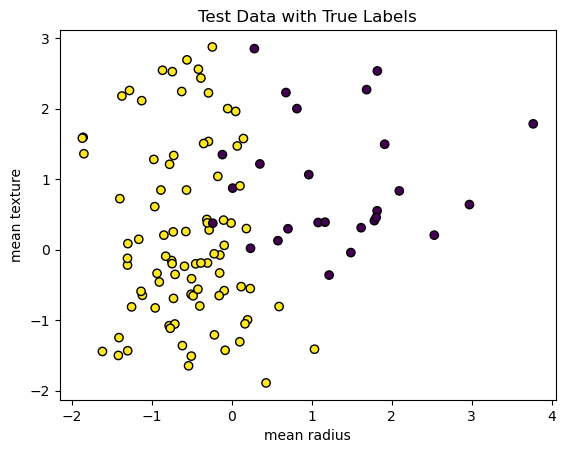

In [65]:
import matplotlib.pyplot as plt
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolors='k')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Test Data with True Labels")
plt.show()